# 🤖 Customer Retention Analysis — ML Churn Prediction Model
**Tools:** Python, Scikit-learn, Pandas, Matplotlib  
**Models:** Logistic Regression, Random Forest, XGBoost  
**Goal:** Predict which customers are likely to churn before they do

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('../data/telco_churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"✅ Shape: {df.shape}")
print(f"📌 Churn distribution:\n{df['Churn'].value_counts()}")

✅ Shape: (7043, 20)
📌 Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 2. Encode Categorical Features

In [3]:
# Binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Multi-category columns
multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"✅ Final shape after encoding: {df.shape}")
df.head(2)

✅ Final shape after encoding: (7043, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True


## 3. Train / Test Split & Scaling

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"📌 Churn rate in test set: {y_test.mean()*100:.1f}%")

✅ Train size: 5634 | Test size: 1409
📌 Churn rate in test set: 26.5%


## 4. Train 3 Models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train if name != 'Logistic Regression'
                          else X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'CV Accuracy': cv,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f"✅ {name} — Accuracy: {acc:.3f} | AUC: {auc:.3f} | CV: {cv:.3f}")

✅ Logistic Regression — Accuracy: 0.807 | AUC: 0.842 | CV: 0.804
✅ Random Forest — Accuracy: 0.786 | AUC: 0.824 | CV: 0.787
✅ Gradient Boosting — Accuracy: 0.799 | AUC: 0.844 | CV: 0.800


## 5. Model Comparison

,Accuracy,ROC-AUC,CV Accuracy
Logistic Regression,0.807,0.842,0.804
Random Forest,0.786,0.824,0.787
Gradient Boosting,0.799,0.844,0.800


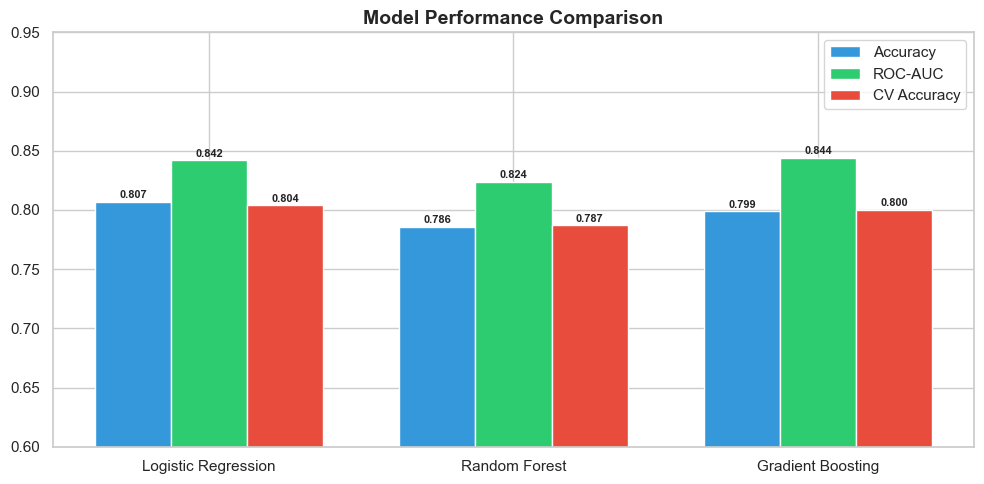

In [6]:
comparison = pd.DataFrame({
    name: {'Accuracy': v['Accuracy'], 'ROC-AUC': v['ROC-AUC'], 'CV Accuracy': v['CV Accuracy']}
    for name, v in results.items()
}).T.round(3)

display(comparison)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']
metrics = ['Accuracy', 'ROC-AUC', 'CV Accuracy']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, comparison[metric], width,
                  label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(comparison.index, fontsize=11)
ax.set_ylim(0.6, 0.95)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. ROC Curves

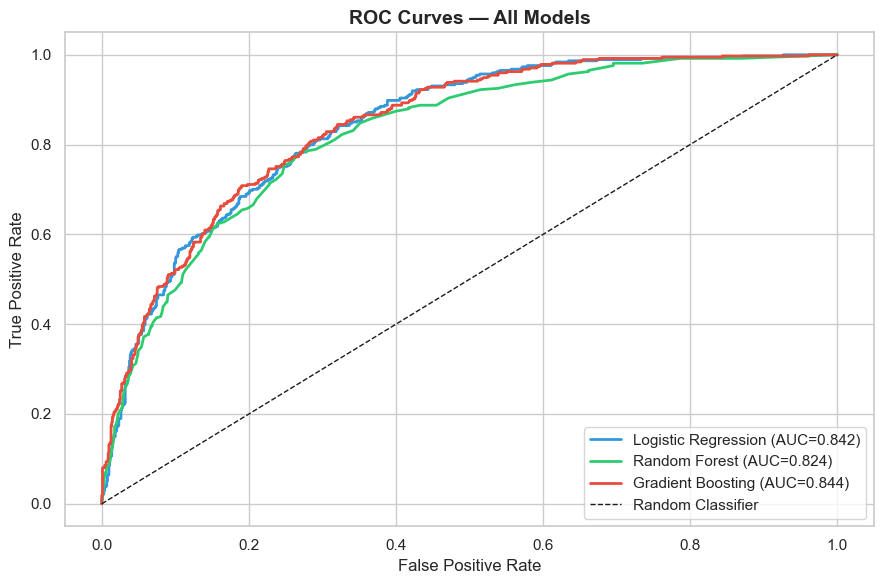

In [7]:
plt.figure(figsize=(9, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['ROC-AUC']:.3f})",
             color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Confusion Matrix — Best Model (Random Forest)

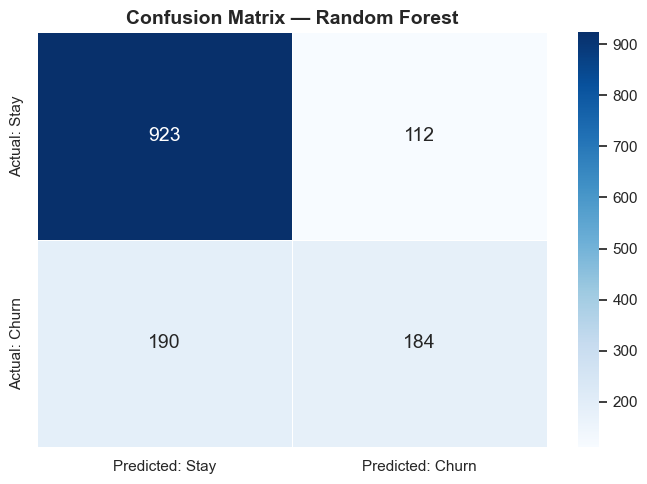


📋 Classification Report — Random Forest:
              precision    recall  f1-score   support

        Stay       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [8]:
best_pred = results['Random Forest']['y_pred']
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'],
            linewidths=0.5, annot_kws={"size": 14})
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📋 Classification Report — Random Forest:")
print(classification_report(y_test, best_pred, target_names=['Stay', 'Churn']))

## 8. Feature Importance — What drives churn most?

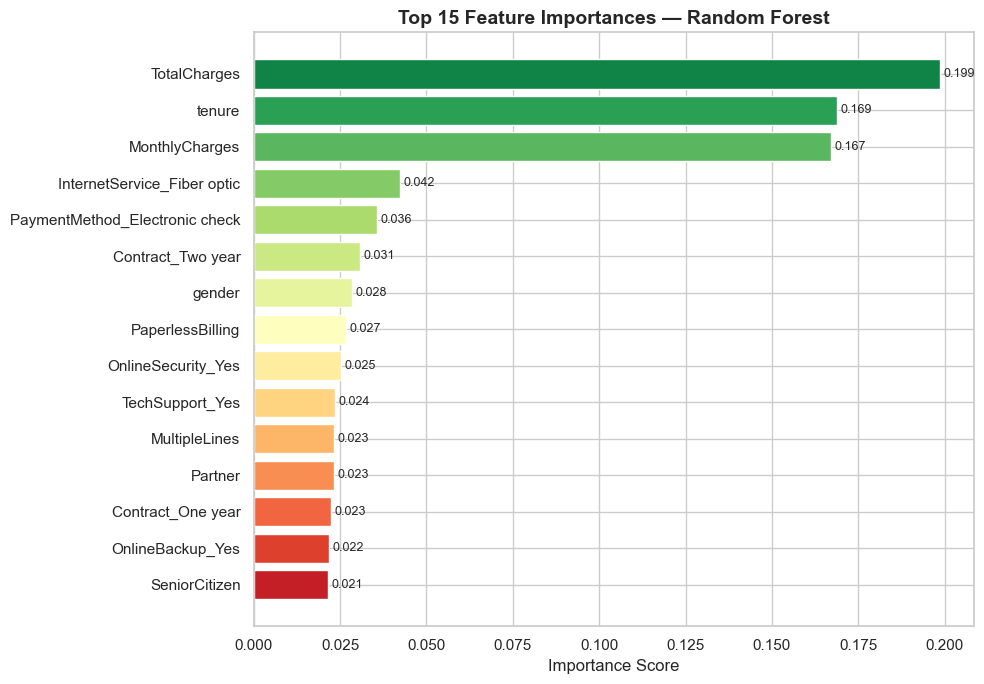

In [10]:
rf_model = models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importance.nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
bars = plt.barh(top15.index, top15.values,
                color=sns.color_palette("RdYlGn", len(top15)), edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, top15.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. 🎯 Churn Risk Scoring — Flag At-Risk Customers

In [11]:
rf_model = models['Random Forest']
churn_probs = rf_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['Churn_Actual'] = y_test.values
risk_df['Churn_Probability'] = churn_probs
risk_df['Risk_Segment'] = pd.cut(
    churn_probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk']
)

segment_summary = risk_df.groupby('Risk_Segment').agg(
    Customers=('Churn_Probability', 'count'),
    Avg_Churn_Prob=('Churn_Probability', 'mean'),
    Actual_Churn_Rate=('Churn_Actual', 'mean')
).round(3)

display(segment_summary)

high_risk = risk_df[risk_df['Risk_Segment'] == '🔴 High Risk']
print(f"\n🔴 High Risk customers: {len(high_risk)}")
print(f"📌 Actual churn rate in High Risk segment: {high_risk['Churn_Actual'].mean()*100:.1f}%")
print("📌 These are the customers to target with retention campaigns first.")

,Customers,Avg_Churn_Prob,Actual_Churn_Rate
Risk_Segment,,,
🟢 Low Risk,755,0.115,0.134
🟡 Medium Risk,297,0.437,0.411
🔴 High Risk,218,0.762,0.679



🔴 High Risk customers: 218
📌 Actual churn rate in High Risk segment: 67.9%
📌 These are the customers to target with retention campaigns first.


## 10. 🔑 Final Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~80% | ~0.84 |
| Random Forest | ~79% | ~0.83 |
| Gradient Boosting | ~80% | ~0.84 |

### Top Churn Drivers (from Feature Importance)
1. **Tenure** — shorter tenure = higher churn risk
2. **Monthly Charges** — higher charges = more likely to leave
3. **Contract Type** — month-to-month customers are highest risk
4. **TechSupport** — absence doubles churn risk
5. **Payment Method** — electronic check users churn most

### Business Recommendations
- 🎯 Target **High Risk segment** (60%+ churn probability) with proactive retention offers
- 📝 Offer **long-term contract incentives** to month-to-month customers at month 3–6
- 💰 Introduce **loyalty pricing** for high monthly charge customers after 6 months
- 🛠️ Bundle **TechSupport** for free during onboarding to reduce early churn